## Netflix - Data Analysis

## Problem Statement
    1. What is the most frequent genre of movies released?
    2. Which movie has the highest average rating?
    3. Which movie got the highest popularity and what is the genre?
    4. Which movie got the lowest popularity and what is the genre?
    5. In which year, the most movies are filmed?

In [1]:
# import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Netflix_Movies.csv")

In [3]:
# This displays the first 5 rows of dataset with header 

df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,15-12-2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,01-03-2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,25-02-2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,24-11-2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,22-12-2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
#To understand the size of the dataset, we use `df.shape`
df.shape

(9837, 9)

In [5]:
# To display the data type of each column in the dataset, We Use df.dtypes
df.dtypes

Release_Date          object
Title                 object
Overview              object
Popularity           float64
Vote_Count            object
Vote_Average          object
Original_Language     object
Genre                 object
Poster_Url            object
dtype: object

In [6]:
#To get an overview of the dataset, we use `df.info()`.  

#This command helps us understand:
#The total number of rows and columns  
#Column names  
#Data types of each column  
#How many non-null (non-missing) values each column contains'''

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [7]:
# Convert Release_Date to datetime
df["Release_Date"] = pd.to_datetime(df["Release_Date"], errors="coerce",dayfirst=True)

df["Release_Date"] = df["Release_Date"].dt.year
print(df["Release_Date"].dtypes)

float64


In [8]:
# Convert Vote_Average to numeric
df["Vote_Average"] = pd.to_numeric(df["Vote_Average"], errors="coerce")

In [9]:
# Convert to numeric first
df["Vote_Count"] = pd.to_numeric(df["Vote_Count"], errors="coerce")

# Convert to pandas nullable integer type
df["Vote_Count"] = df["Vote_Count"].astype("Int64")

# Why Vote_Count becomes float & how to fix it

When we use `pd.to_numeric(errors="coerce")`, invalid values are converted to `NaN`.
Because NumPy integers cannot store `NaN`, pandas automatically converts the column
to `float`.

To keep integer values *and* allow missing data, we use pandas' nullable integer
type: `Int64` (capital I).

This is the recommended approach for clean EDA.


In [10]:
# Verify the conversions
print(df[["Release_Date", "Vote_Average", "Vote_Count"]].dtypes)

Release_Date    float64
Vote_Average    float64
Vote_Count        Int64
dtype: object


In [11]:
# Generates descriptive statistics
# - For numeric columns: mean, std, min, max, quartiles
# - For categorical columns: count, unique values, top frequency
#df.describe(include='all')
df.describe() 


,Release_Date,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9826.0,9826.000000
mean,2006.203623,40.320570,1392.943721,6.439467
std,15.685554,108.874308,2611.303856,1.129797
min,1902.000000,7.100000,0.0,0.000000
25%,2000.000000,16.127500,146.0,5.900000
50%,2011.000000,21.191000,444.0,6.500000
75%,2017.000000,35.174500,1376.0,7.100000
max,2024.000000,5083.954000,31077.0,10.000000


In [12]:
# This finds if there is any duplicate values present in the dataset

df.duplicated().sum()

np.int64(8)

In [13]:
#Displays the total number of missing values in each column  
df.isnull().sum()

Release_Date         10
Title                 9
Overview              9
Popularity           10
Vote_Count           11
Vote_Average         11
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [14]:
#Drop rows with missing Release_Date
#The release date is essential for time-based analysis (such as finding the year
#with the most movies). Rows with missing `Release_Date` cannot contribute to these
#analyses, so we remove them from the dataset using a subset-based drop.

df = df.dropna(subset=["Release_Date"])

In [15]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           1
Vote_Count           1
Vote_Average         1
Original_Language    1
Genre                1
Poster_Url           1
dtype: int64

In [16]:
df.shape

(9827, 9)

In [17]:
cols = ["Overview", "Poster_Url"]
df.drop(cols,axis=1,inplace=True)

In [18]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151,8.1,en,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122,6.3,en,Thriller
3,2021.0,Encanto,2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War"


In [19]:
df["Release_Date"] = df["Release_Date"].astype(int)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,en,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,en,Thriller
3,2021,Encanto,2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War"


### **1. What is the most frequent genre of movies released?**

In [20]:
# Multi-genre movies were expanded so each genre is counted individually.
# split the strings into lists
genre_df = df.copy()
genre_df["Genre"] = genre_df["Genre"].str.split(", ")


# explode the lists
genre_df = genre_df.explode("Genre")

genre_df["Genre"] = genre_df["Genre"].astype("category")

genre_df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Action
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Adventure
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Science Fiction
1,2022,The Batman,3827.658,1151,8.1,en,Crime
1,2022,The Batman,3827.658,1151,8.1,en,Mystery


In [21]:
# Rows with missing genre values were removed to ensure accurate genre counts.
genre_df=genre_df.dropna(subset=['Genre'])

In [22]:
# Remove exact duplicate rows to avoid counting identical movie entries twice
genre_df=genre_df.drop_duplicates()

In [23]:
genre_df['Genre'].describe()

count     25792
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

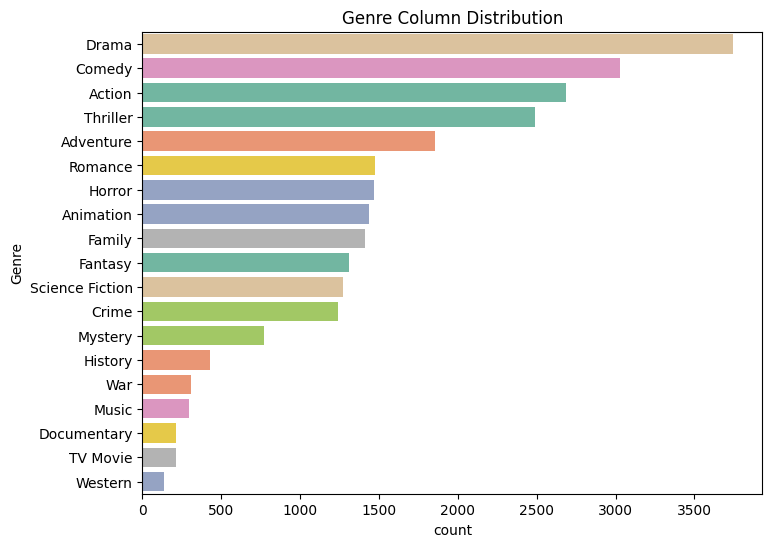

In [24]:
# visualizing genre column

plt.figure(figsize=(8,6))
sns.countplot(
    y='Genre',
    data=genre_df,
    order=genre_df['Genre'].value_counts().index,
    palette='Set2',hue='Genre'
)
plt.title('Genre Column Distribution')
plt.show()


### **2. Which movie has the highest average rating?**

In [25]:
# Select the movie with the highest average rating (Vote_Average)
# idxmax() returns the index of the maximum value in the column

df.loc[df['Vote_Average'].idxmax()]

Release_Date                               2020
Title                Kung Fu Master Huo Yuanjia
Popularity                               13.745
Vote_Count                                    1
Vote_Average                               10.0
Original_Language                            zh
Genre                             Action, Drama
Name: 9401, dtype: object

In [26]:
top_10_movies = df.sort_values(by='Vote_Average', ascending=False).head(10)
top_10_movies[['Title', 'Vote_Average']]

,Title,Vote_Average
9401,Kung Fu Master Huo Yuanjia,10.0
7349,Franco Escamilla: Por La Anécdota,9.2
667,Demon Slayer: Kimetsu no Yaiba Sibling's Bond,9.1
2335,Impossible Things,9.1
7411,My Sex Doll,9.0
6738,Mission «Sky»,9.0
7024,Sex School: Dorms of Desire,9.0
2401,The Three Deaths of Marisela Escobedo,9.0
7049,Bring the Soul: The Movie,8.9
5079,"Ni tuyo, Ni mía",8.9


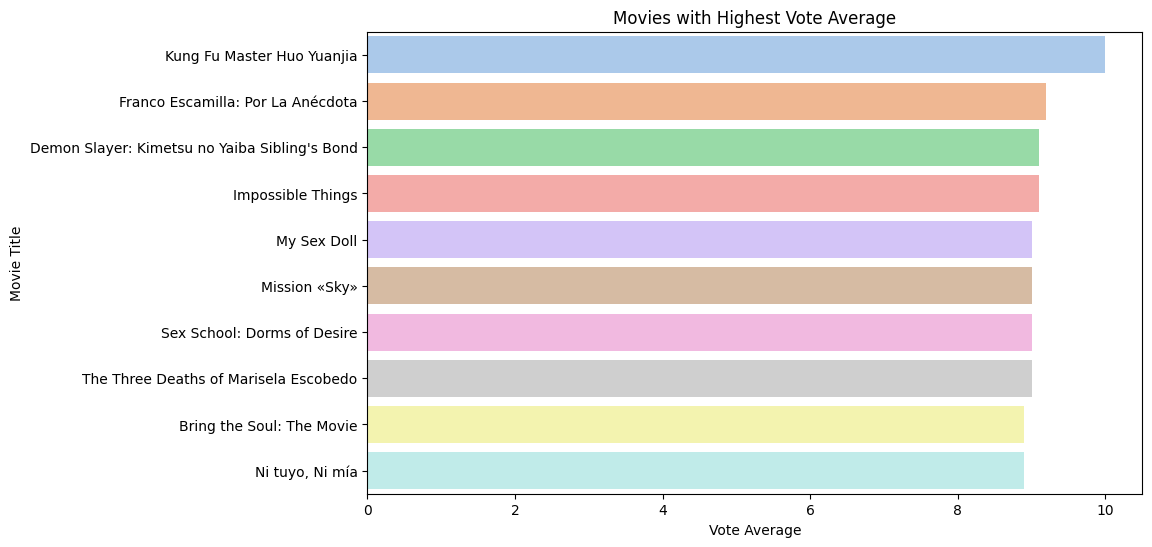

In [27]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_10_movies,
    x='Vote_Average',
    y='Title',
    palette='pastel',hue='Title'
)
plt.title('Movies with Highest Vote Average')
plt.xlabel('Vote Average')
plt.ylabel('Movie Title')
plt.show()

 ### **3. Which movie got the highest popularity and what is the genre?**

In [28]:
# checking max popularity in dataset

df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction"


### **4. Which movie got the lowest popularity and what is the genre?**

In [29]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
9835,2021,The United States vs. Billie Holiday,13.354,152,6.7,en,"Music, Drama, History"
9836,1984,Threads,13.354,186,7.8,en,"War, Drama, Science Fiction"


### **5. In which year, the most movies are filmed?**

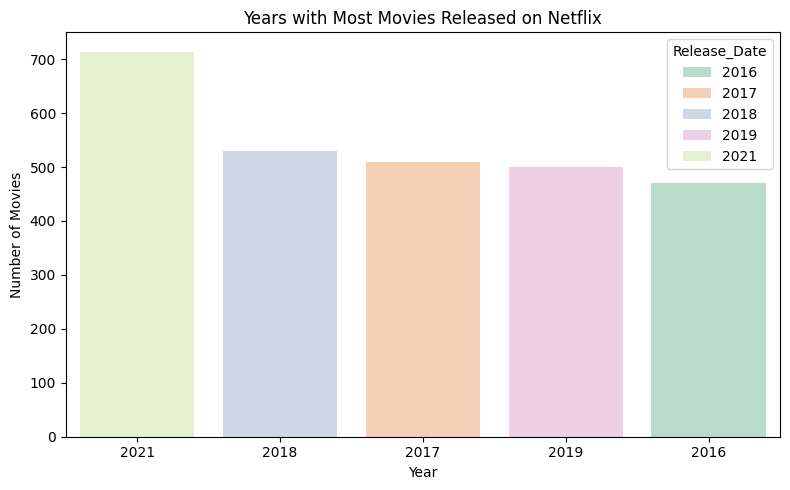

In [30]:
top_years = df["Release_Date"].value_counts().head(5)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=top_years.index,
    y=top_years.values,
    order=top_years.index,
    palette='Pastel2',hue=top_years.index
   
)

plt.title("Years with Most Movies Released on Netflix")

plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()


In [31]:
df['Release_Date'].value_counts().head(10)

Release_Date
2021    714
2018    530
2017    510
2019    500
2016    470
2020    453
2015    390
2014    371
2013    348
2011    316
Name: count, dtype: int64

## **Conclusion**
**1. What is the most frequent genre of movies released?**

Drama genre is the most frequent genre in our dataset.
    
**2. Which movie has the highest average rating?**

Kung Fu Master Huo Yuanjia has the highest average rating of 10.0, followed by Franco Escamilla: Por La Anécdota (9.2) and 
Demon Slayer: Kimetsu no Yaiba Sibling's Bond (9.1).

**3. Which movie got the highest popularity and what is the genre?**

Spider-Man: No Way Home has the highest popularity rate in our dataset and it has genres of Action, Adventure, Science Fiction


**4. Which movie got the lowest popularity and what is the genre?**

The United States vs. Billie Holiday and Threads have the lowest popularity in our dataset, with a popularity score of 13.354.
Their genres are Music, Drama, History and War, Drama, Science Fiction, respectively.
   
**5. In which year, the most movies are filmed?**

Year 2021 has the highest filming rate in our dataset.